In [4]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

In [6]:
from pathlib import Path

candidate_paths = [
	Path("data/creditcard.csv"),
	Path("notebooks/data/creditcard.csv"),
	Path("../data/creditcard.csv"),
	Path("..") / "data" / "creditcard.csv",
]

csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
	raise FileNotFoundError(
		"Could not find 'creditcard.csv'. "
		"Update the search paths in this cell to match your dataset location."
	)

df = pd.read_csv(csv_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.shape

(284807, 31)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

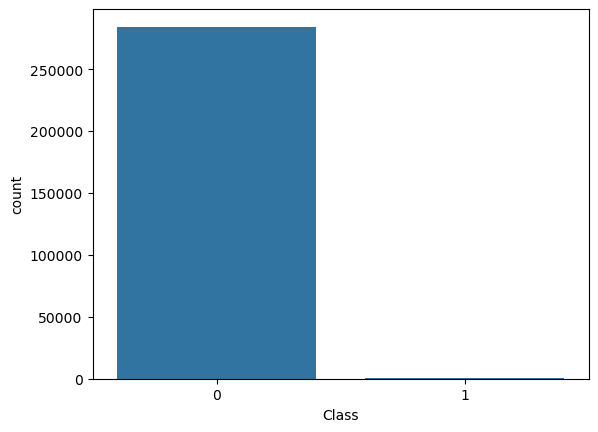

In [11]:
sns.countplot(x='Class', data=df)
plt.show()

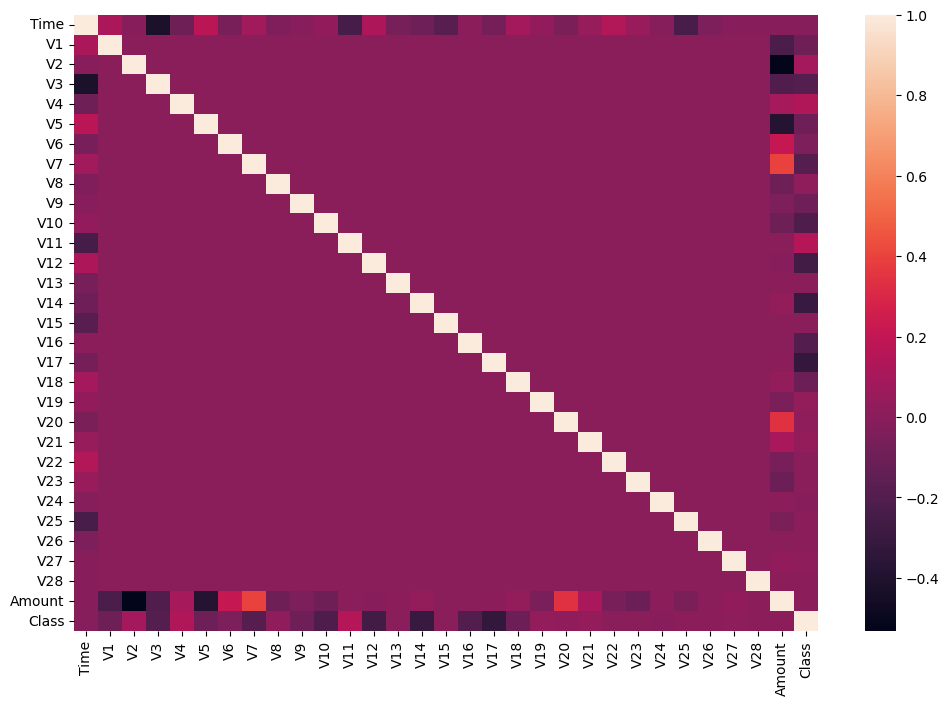

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr())
plt.show()

In [13]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [16]:
y_train_smote.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [17]:
lr = LogisticRegression(
        max_iter=1000
)

lr.fit(
    X_train_smote,
    y_train_smote
)

d:\anacondaa\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [18]:
y_pred_lr = lr.predict(X_test)

In [19]:
print(classification_report(
      y_test,
      y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



In [20]:
precision_score(y_test,y_pred_lr)

recall_score(y_test,y_pred_lr)

f1_score(y_test,y_pred_lr)

0.21890547263681592

In [21]:
y_prob_lr = lr.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    y_prob_lr
)

np.float64(0.9753256606525559)

In [22]:
rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42
)

rf.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(random_state=42)

In [23]:
y_pred_rf = rf.predict(X_test)

In [24]:
print(classification_report(
      y_test,
      y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [25]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    y_prob_rf
)

np.float64(0.9644234399584257)

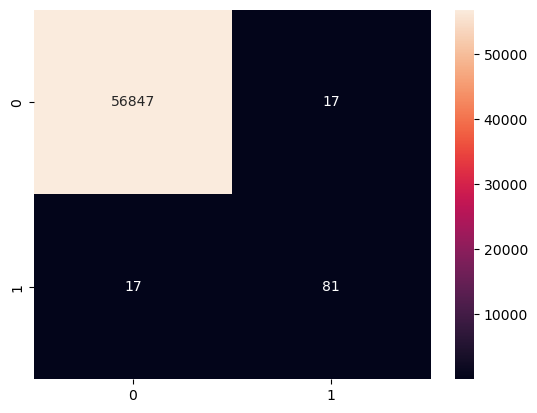

In [26]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.show()

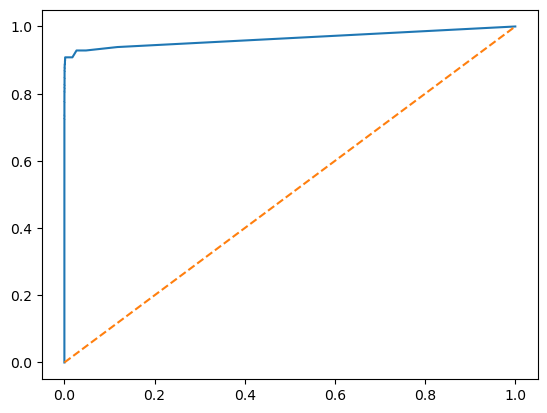

In [27]:
fpr,tpr,_ = roc_curve(
    y_test,
    y_prob_rf
)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.show()

In [28]:
from sklearn.model_selection import GridSearchCV

params = {
    'C':[0.01,0.1,1,10]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5,
    scoring='recall'
)

grid_lr.fit(
    X_train_smote,
    y_train_smote
)

d:\anacondaa\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\anacondaa\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10]}, scoring='recall')

In [31]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_smote,
    y_train_smote
)

best_model = rf

In [33]:
import joblib

joblib.dump(
    rf,
    "fraud_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!
